In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import os
import glob
import re
import ipywidgets as widgets
from IPython.display import display

%matplotlib widget

In [2]:
SNAP_DIR = 'Runs/Run_1/snaps'
MAX_N    = 171   # neutron axis limit
MAX_Z    = 111   # proton axis limit
CMAP     = 'plasma'
VMIN_LOG = -15   # log10 floor for colorbar
VMAX_LOG =  0    # log10 ceiling (x <= 1)

In [3]:
def parse_snapshot(path):
    """Parse one WinNet snapshot file.

    Returns (time [s], T9 [GK], rho [g/cm^3], df)
    where df has columns [N, Z, A, Y, X].
    """
    with open(path) as fh:
        lines = fh.readlines()

    # line 0: "    time    temp    dens"   (header – skip)
    # line 1: actual time / T9 / rho values
    vals = lines[1].split()
    time = float(vals[0])
    T9   = float(vals[1])
    rho  = float(vals[2])
    # line 2: "     nin     zin       y       x"  (column header – skip)
    # lines 3+: nucleus data
    data_str = ''.join(lines[3:])
    df = pd.read_csv(
        StringIO(data_str),
        sep=r'\s+', header=None,
        names=['N', 'Z', 'Y', 'X'],
        dtype={'N': int, 'Z': int, 'Y': float, 'X': float},
    )
    df['A'] = df['N'] + df['Z']
    return time, T9, rho, df

In [4]:
snap_files = sorted(
    glob.glob(os.path.join(SNAP_DIR, 'snapsh_*.dat')),
    key=lambda p: int(re.search(r'snapsh_(\d+)\.dat', os.path.basename(p)).group(1))
)
print(f"Found {len(snap_files)} snapshots")

Found 5737 snapshots


In [5]:
X_FLOOR = 1e-30  # abundances at or below this are treated as absent (white)

def build_heatmap(df):
    matrix = np.full((MAX_Z + 1, MAX_N + 1), np.nan)
    mask = df['X'] > X_FLOOR
    for _, row in df[mask].iterrows():
        z, n = int(row['Z']), int(row['N'])
        if 0 <= z <= MAX_Z and 0 <= n <= MAX_N:
            matrix[z, n] = np.log10(row['X'])
    return matrix

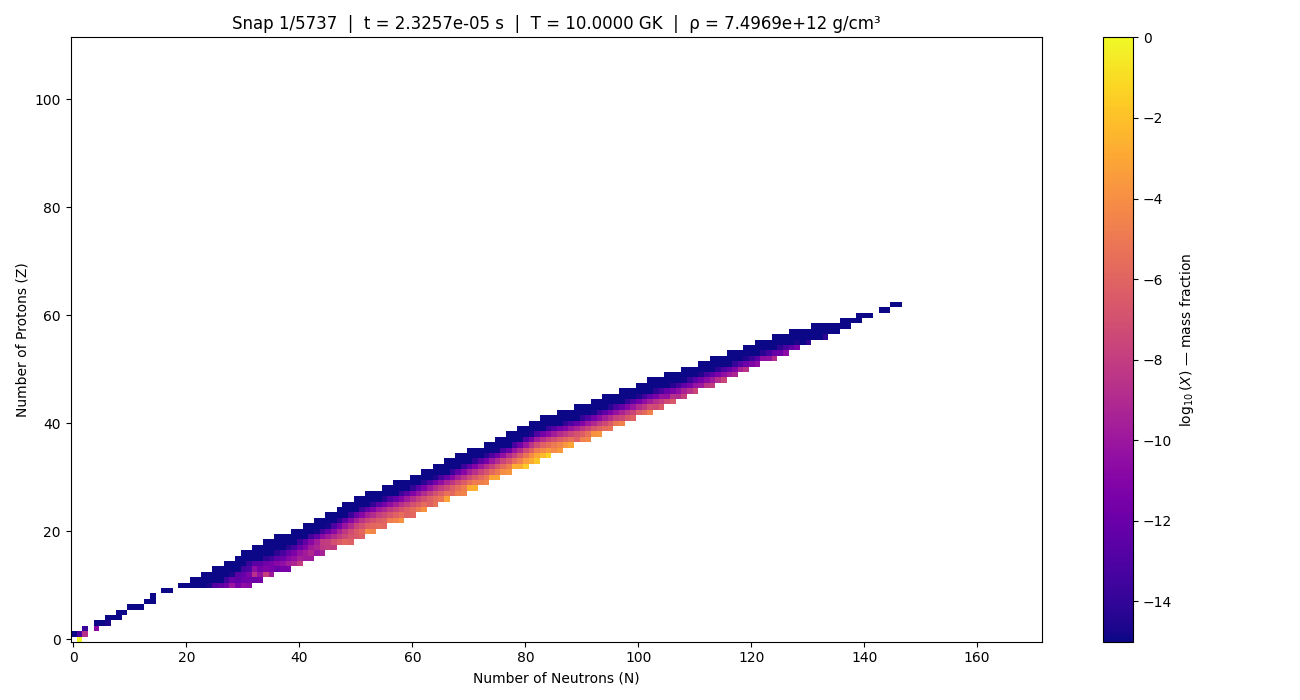

In [6]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlabel("Number of Neutrons (N)")
ax.set_ylabel("Number of Protons (Z)")
ax.set_facecolor('white')  # background colour for absent nuclei

# Colormap: NaN (zero abundance) → white
cmap_obj = plt.get_cmap(CMAP).copy()
cmap_obj.set_bad(color='white')

# Initial chart: first snapshot
time0, T9_0, rho0, df0 = parse_snapshot(snap_files[0])
mat0 = build_heatmap(df0)

img = ax.imshow(
    mat0, origin='lower', cmap=cmap_obj, aspect='auto',
    vmin=VMIN_LOG, vmax=VMAX_LOG,
    extent=[-0.5, MAX_N + 0.5, -0.5, MAX_Z + 0.5],
)
cbar = fig.colorbar(img, ax=ax, label=r'$\log_{10}(X)$ — mass fraction')
title = ax.set_title(
    f"Snap 1/{len(snap_files)}  |  "
    f"t = {time0:.4e} s  |  T = {T9_0:.4f} GK  |  ρ = {rho0:.4e} g/cm³"
)
plt.tight_layout()

In [7]:
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(snap_files) - 1,
    description='Snapshot:',
    continuous_update=False,
    layout=widgets.Layout(width='80%'),
    style={'description_width': '100px'},
)

def update(change):
    idx = change['new']
    time_i, T9_i, rho_i, df_i = parse_snapshot(snap_files[idx])
    mat_i = build_heatmap(df_i)
    img.set_data(mat_i)
    title.set_text(
        f"Snap {idx + 1}/{len(snap_files)}  |  "
        f"t = {time_i:.4e} s  |  T = {T9_i:.4f} GK  |  ρ = {rho_i:.4e} g/cm³"
    )
    fig.canvas.draw_idle()

slider.observe(update, names='value')
display(slider)

IntSlider(value=0, continuous_update=False, description='Snapshot:', layout=Layout(width='80%'), max=5736, sty…